<a href="https://colab.research.google.com/github/OrastaRakhmatullayeva/ML-projects/blob/main/desicion_tree_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text

URL = "https://raw.githubusercontent.com/kb22/" \
      "Heart-Disease-Prediction/master/dataset.csv"
df = pd.read_csv(URL)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df.duplicated().sum()

np.int64(1)

In [9]:
df.drop_duplicates(inplace=True)

<Axes: >

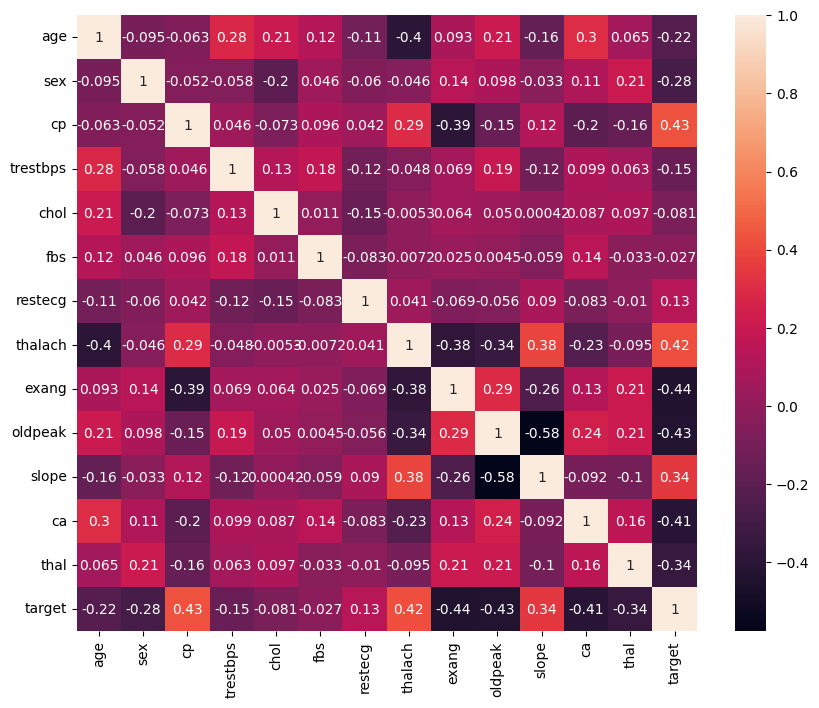

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),annot=True)

In [14]:
X=df.drop(columns=['target'])
y=df['target']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,
                                               random_state=42)

In [15]:
model=DecisionTreeClassifier(max_depth=5,random_state=42)

model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [16]:
print("The score of training set : ",model.score(X_train,y_train))

print("The score of testing set : ",model.score(X_test,y_test))

The score of training set :  0.91701244813278
The score of testing set :  0.8032786885245902


<Axes: >

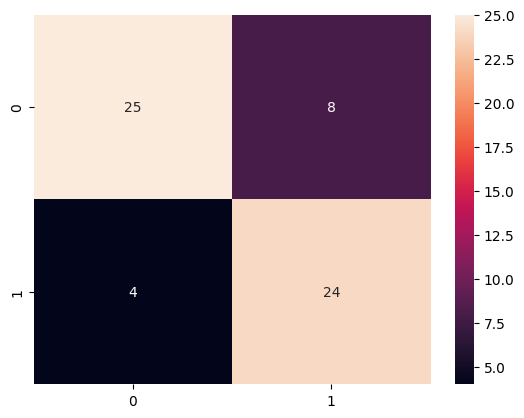

In [20]:
from sklearn.metrics import confusion_matrix

y_pred=model.predict(X_test)

cm=confusion_matrix(y_pred,y_test)
sns.heatmap(cm,annot=True)

In [29]:
from sklearn.model_selection import GridSearchCV,StratifiedKFold
from time import time

start=time()
params={
    'max_depth':[5,10,20,50],
    'criterion':['gini', 'entropy', 'log_loss'],
    'min_samples_split':[2,5,7,20]
}

cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

grid=GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    cv=cv
)

grid.fit(X_train,y_train)

end=time()
print("Time totally it took:",end-start,' s')
print("The best parameters: ",grid.best_params_)
print("The best score :",grid.best_score_)

Time totally it took: 2.292362928390503  s
The best parameters:  {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 20}
The best score : 0.7181122448979591


In [34]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8032786885245902

Confusion Matrix:
[[27  2]
 [10 22]]
